In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

plt.style.use("seaborn-v0_8-colorblind")


def rolling_mean(series, window):
    s = pd.to_numeric(series, errors="coerce")
    return s.rolling(window=window, min_periods=1).mean()


def find_col(df, candidates):
    for cand in candidates:
        for col in df.columns:
            if col.strip() == cand.strip():
                return col
    return None

In [2]:
MANIFESTACIONES = {
    "nat": {
        "label": "No al Tarifazo",
        "path": "epsilon_sq/nat/results/Epsilon_values.txt",
        "hora_critica": 429624,
        "gris": [
            (429580, 429587),
            (429604, 429611),
            (429628, 429635),
            (429652, 429659),
        ],
        "naranja": [(429620, 429628)],
    },
    "9n": {
        "label": "9N",
        "path": "epsilon_sq/9n/results/Epsilon_values.txt",
        "hora_critica": 437037,
        "gris": [
            (436996, 437003),
            (437020, 437027),
            (437044, 437051),
            (437068, 437075),
        ],
        "naranja": [
            (437033, 437043),
            (437059, 437062),
            (437013, 437018),
        ],
    },
    "ch": {
        "label": "Charlie Hebdo",
        "path": "epsilon_sq/ch/results/Epsilon_values.txt",
        "hora_critica": 394717,
        "gris": [
            (394680, 394687),
            (394704, 394711),
            (394728, 394735),
            (394752, 394754),
        ],
        "naranja": [(394716, 394724)],
    },
}

MANIFESTACION_ORDER = ["nat", "9n", "ch"]


def cargar_epsilon(path):
    df = pd.read_csv(path, sep="\t")
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(
        columns={
            r"$\epsilon_{\ccdf}$": "eps_ccdf",
            r"$\epsilon_{\knn}$": "eps_knn",
            r"$\epsilon_{\cco}$": "eps_cco",
        }
    )

    network_col = find_col(df, ["Network", "network", "NETWORK"])
    cco_col = find_col(df, [r"$\epsilon_{\cco}$", "eps_cco"])

    if network_col is None:
        raise ValueError(f"No se encontró la columna 'Network' en {path}")
    if cco_col is None:
        raise ValueError(f"No se encontró la columna eps_cco en {path}")

    return df[network_col], df[cco_col]


def horas_a_fecha(x_val, pos):
    fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
    return fecha.strftime("%d-%b %Hh")


def decorar_subplot(ax, config):
    ax.axvline(config["hora_critica"], linestyle="-.", color="green")

    for x0, x1 in config["gris"]:
        ax.axvspan(x0, x1, color="gray", alpha=0.4)

    for x0, x1 in config["naranja"]:
        ax.axvspan(x0, x1, color="orange", alpha=0.4)

    ax.grid(True, linestyle="--", alpha=0.4)
    ax.margins(x=0.01)
    ax.tick_params(axis="both", which="major", labelsize=10)


epsilon_data = {key: cargar_epsilon(cfg["path"]) for key, cfg in MANIFESTACIONES.items()}

/tmp/ipykernel_97805/2872718734.py:70: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


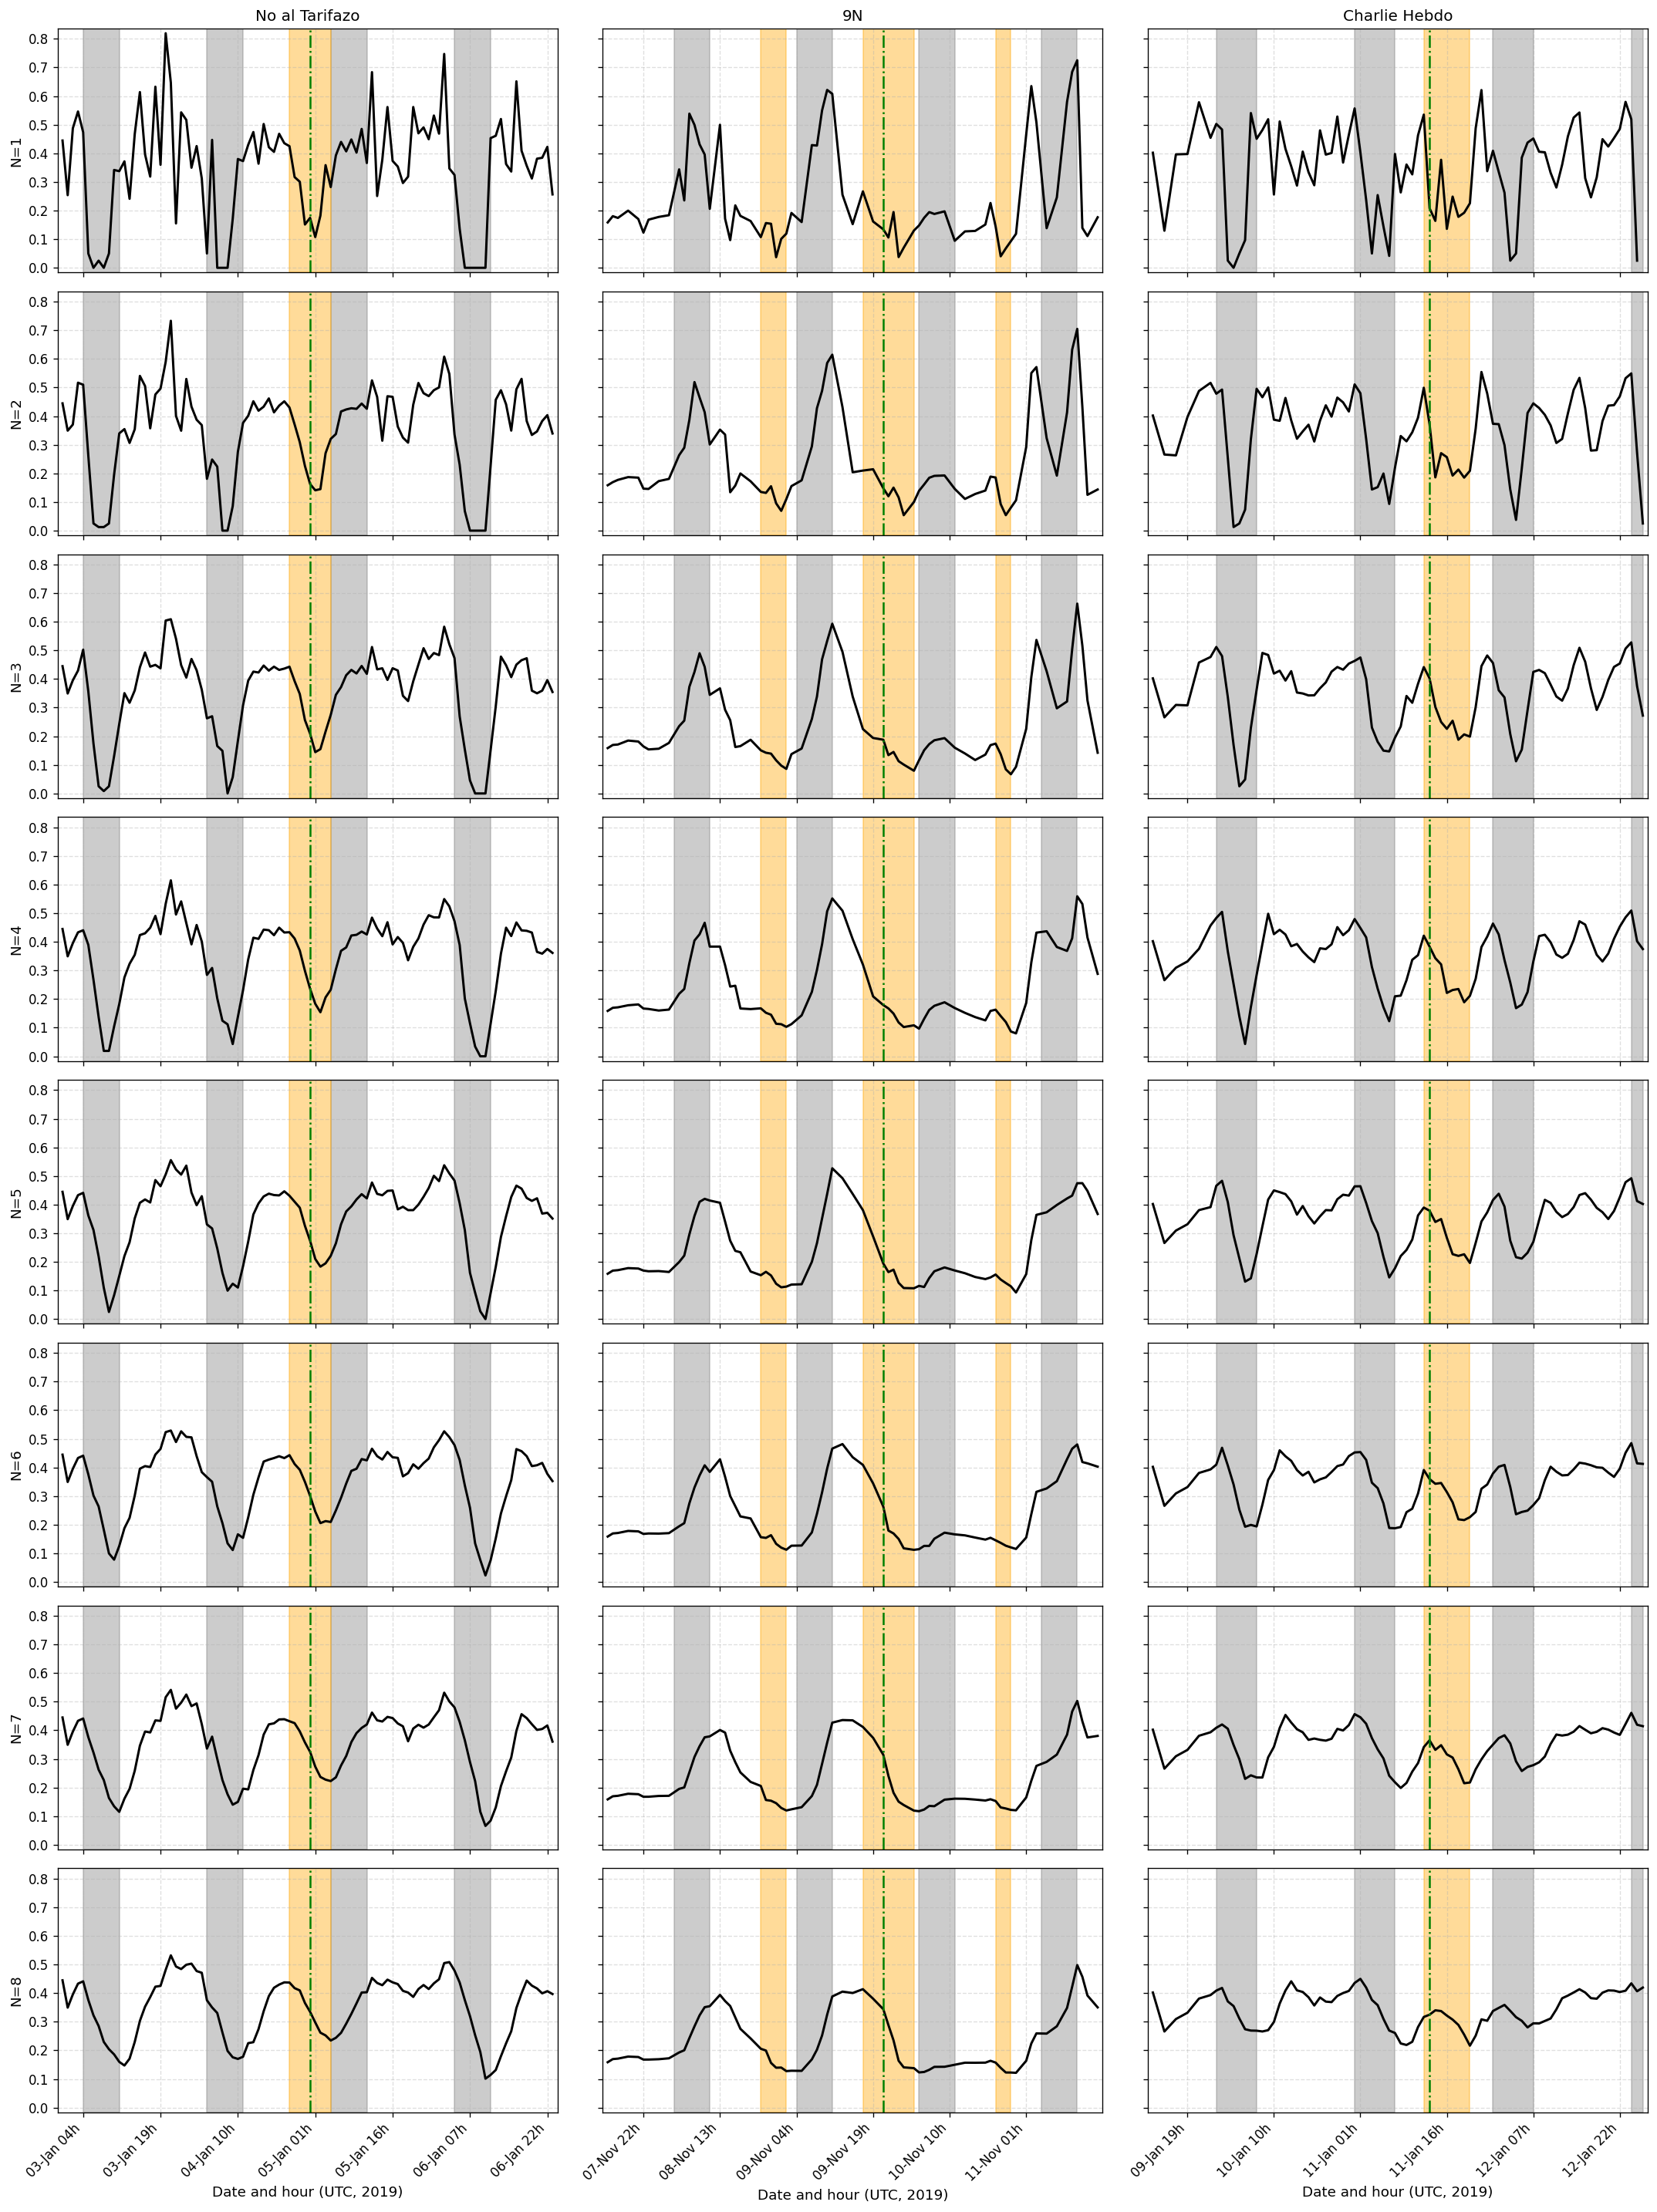

In [3]:
y_min = np.inf
y_max = -np.inf
for key in MANIFESTACION_ORDER:
    x, y = epsilon_data[key]
    for N in range(1, 9):
        y_ma = rolling_mean(y, N)
        y_min = min(y_min, float(y_ma.min()))
        y_max = max(y_max, float(y_ma.max()))

y_margin = (y_max - y_min) * 0.02 if y_max > y_min else 0.01
y_lim = (y_min - y_margin, y_max + y_margin)

fig, axes = plt.subplots(8, 3, figsize=(18, 24), dpi=120, sharex="col", sharey=True)

for row_idx, N in enumerate(range(1, 9)):
    for col_idx, key in enumerate(MANIFESTACION_ORDER):
        config = MANIFESTACIONES[key]
        x, y = epsilon_data[key]
        ax = axes[row_idx, col_idx]

        y_ma = rolling_mean(y, N)
        ax.plot(x, y_ma, linewidth=1.8, c="black")
        decorar_subplot(ax, config)
        ax.set_ylim(y_lim)

        if row_idx == 0:
            ax.set_title(config["label"], fontsize=12)

        if col_idx == 0:
            ax.set_ylabel(f"N={N}", fontsize=11)

        if row_idx == 7:
            ax.xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
            ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
            ax.set_xlabel("Date and hour (UTC, 2019)", fontsize=11)
            for tick in ax.get_xticklabels():
                tick.set_rotation(45)
                tick.set_ha("right")
        else:
            plt.setp(ax.get_xticklabels(), visible=False)

plt.tight_layout()
plt.show()

/home/msuarez/Escritorio/self_similarity/main_branch/github/self-similarity-in-social-movements/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ch W=5h: 100%|██████████| 92/92 [01:15<00:00,  1.22it/s]
/tmp/ipykernel_97805/2872718734.py:70: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


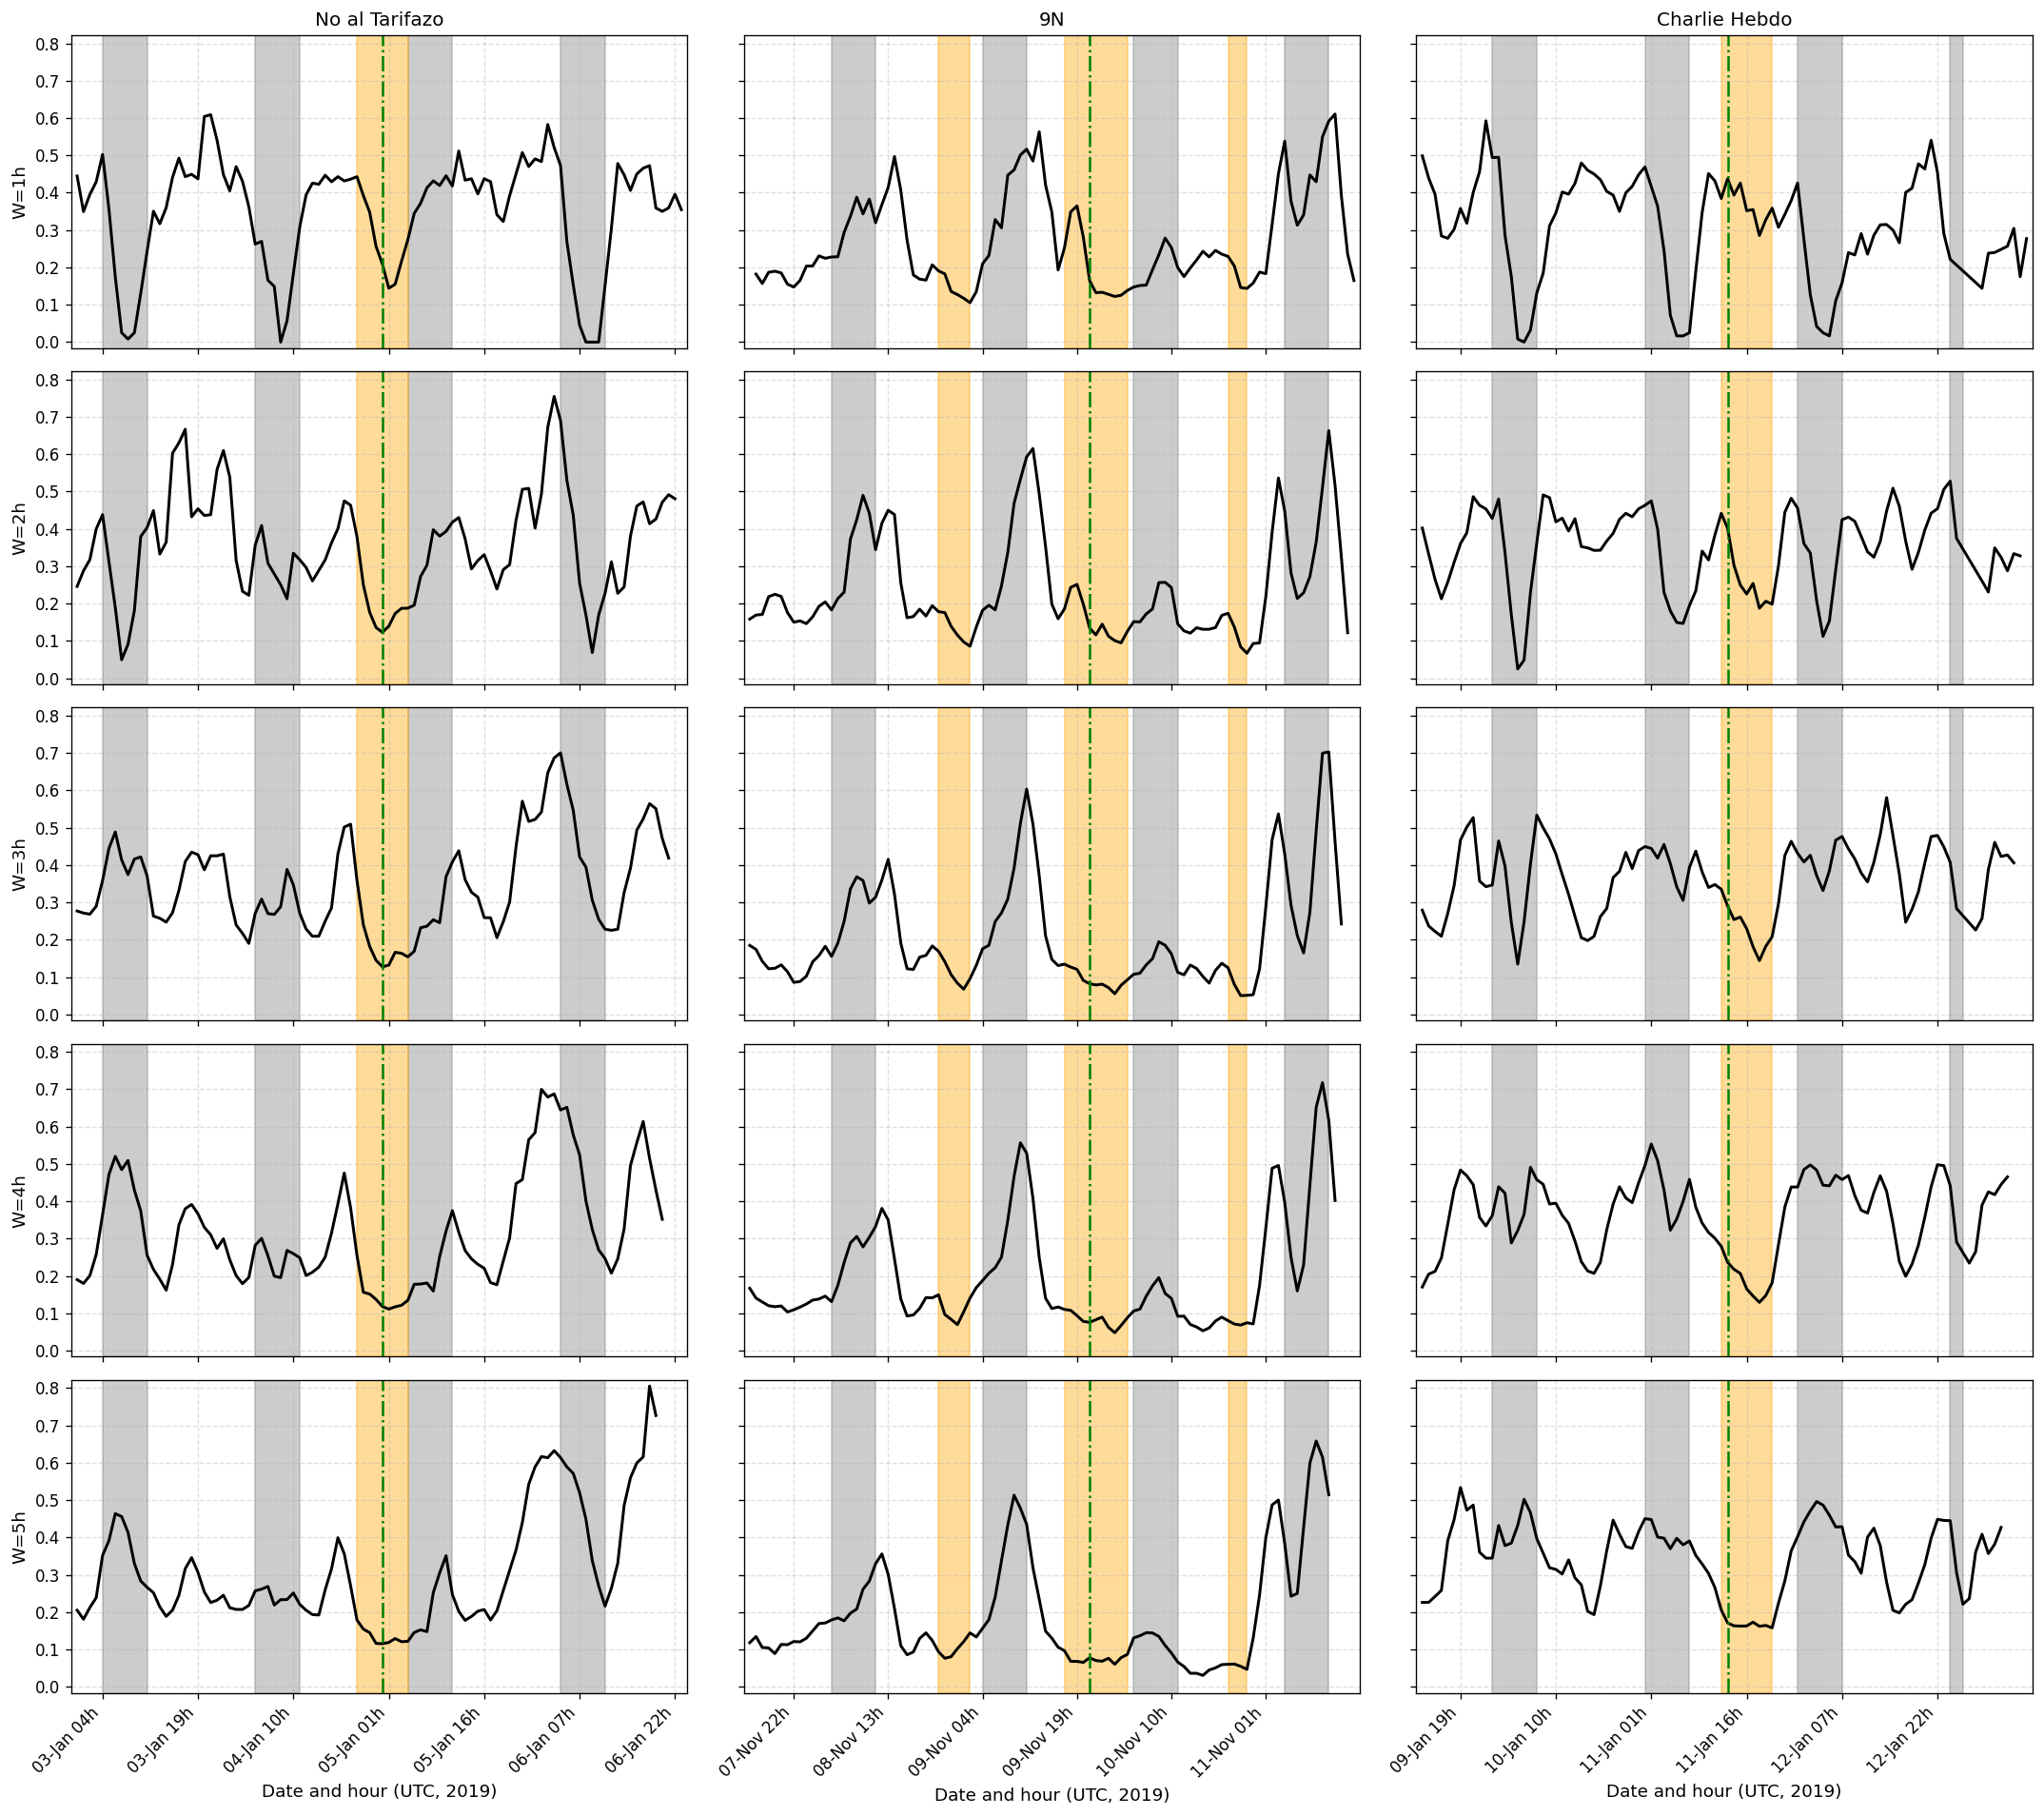

In [4]:
import os
from collections import defaultdict

import networkx as nx
from tqdm.auto import tqdm

from utils_graphs import gexf_a_edge, get_dict_hora_kt, read_data

N_SMOOTH = 3
HOUR_WINDOWS = [1, 2, 3, 4, 5]
NBINS = 20
DATASETS_FOLDER = "datasets/csvs/"
GRAPHS_FOLDER = "graphs/"
EPSILON_BASE = "epsilon_sq/"

HOUR_RANGES = {
    "nat": (429576, 429672),
    "9n": (MANIFESTACIONES["9n"]["hora_critica"] - 72, MANIFESTACIONES["9n"]["hora_critica"] + 72),
    "ch": (MANIFESTACIONES["ch"]["hora_critica"] - 48, MANIFESTACIONES["ch"]["hora_critica"] + 48),
}

EDGE_CRITERIA = {"hashtag": "user"}


def Read_Graph(Add, Network, Threshold):
    G = nx.read_edgelist(Add + f"{Network}/{Network}.edge", data=False)
    G.remove_edges_from(nx.selfloop_edges(G))
    largest_cc = max(nx.connected_components(G), key=len)
    if len(largest_cc) != G.number_of_nodes():
        S = [G.subgraph(c).copy() for c in sorted(nx.connected_components(G), key=len, reverse=True)]
        G = S[0]
    rm = [n for (n, d) in G.degree() if d <= Threshold]
    G.remove_nodes_from(rm)
    G.remove_nodes_from(list(nx.isolates(G)))
    return G


def Read_original_Graph(Add, Network):
    G = nx.read_edgelist(Add + f"{Network}/{Network}.edge", data=False)
    G.remove_edges_from(nx.selfloop_edges(G))
    largest_cc = max(nx.connected_components(G), key=len)
    if len(largest_cc) != G.number_of_nodes():
        S = [G.subgraph(c).copy() for c in sorted(nx.connected_components(G), key=len, reverse=True)]
        G = S[0]
    return G


def Compute_Metric_CCO(G, Res):
    degree_dict = dict(G.degree())
    filtered_clustering = {
        node: cc for node, cc in nx.clustering(G).items() if degree_dict[node] > 1
    }
    if filtered_clustering:
        avg_clustering_coefficient = sum(filtered_clustering.values()) / len(filtered_clustering)
    else:
        avg_clustering_coefficient = 0

    d = defaultdict(list)
    if G.number_of_nodes() != 0:
        Avg_Degree = sum([deg for (_, deg) in nx.degree(G)]) / float(G.number_of_nodes())
    else:
        Avg_Degree = 0

    for u in G.nodes():
        d[G.degree(u) / Avg_Degree].append(u)

    for degree in d:
        clustering_coeff = nx.clustering(G, d[degree])
        pp = sum(clustering_coeff.values()) / len(clustering_coeff)
        pp2 = pp / avg_clustering_coefficient if avg_clustering_coefficient != 0 else 0
        Res[degree].append(pp2)
    return Res


def Compute_Metric_ccdf(G, Res):
    d = defaultdict(list)
    if G.number_of_nodes() > 0:
        Avg_Degree = sum([dd for (_, dd) in nx.degree(G)]) / float(G.number_of_nodes())
        for u in G.nodes():
            d[G.degree(u) / Avg_Degree].append(u)

        Deg_G = defaultdict(list)
        for degree in d:
            Deg_G[degree].append(len(d[degree]) / G.number_of_nodes())

        sorted_Deg_G = {key: Deg_G[key] for key in sorted(Deg_G)}
        cs = np.cumsum(np.array(list(sorted_Deg_G.values())))
        cs2 = 1 - cs
        cs3 = np.insert(cs2, 0, 1)
        cs3 = cs3[:-1]

        for jj, degree in enumerate(sorted_Deg_G):
            Res[degree].append(cs3[jj])
    return Res


def compute_Metric_knn(G, Res):
    Avg_Degree = sum([dd for (_, dd) in nx.degree(G)]) / float(G.number_of_nodes())
    Avg_Degree2 = sum([d**2 for (_, d) in nx.degree(G)]) / float(G.number_of_nodes())

    d = defaultdict(list)
    for u in G.nodes():
        d[G.degree(u) / Avg_Degree].append(u)
    Avg_Neigh_Deg = nx.average_neighbor_degree(G)

    for degree in d:
        Avg = 0
        Temp = d[degree]
        for jj in range(len(Temp)):
            Avg = Avg + Avg_Neigh_Deg[Temp[jj]]
        Avg = Avg / len(Temp)
        Res[degree].append(Avg / (Avg_Degree2 / Avg_Degree))
    return Res


def make_bins(intval1, intval2, nbins):
    nonzero_vals1 = [degree for degree in intval1 if degree > 0]
    if len(nonzero_vals1) == 0:
        raise ValueError("All values are zero; cannot create logarithmic bins.")

    x0_1 = min(nonzero_vals1)
    xf_1 = max(nonzero_vals1)

    nonzero_vals2 = [degree for degree in intval2 if degree > 0]
    if len(nonzero_vals2) == 0:
        raise ValueError("All values are zero; cannot create logarithmic bins.")

    x0_2 = min(nonzero_vals2)
    xf_2 = max(nonzero_vals2)

    x0 = max(x0_1, x0_2)
    xf = min(xf_1, xf_2)
    xq = (xf / x0) ** (1 / nbins)

    x_exp = np.zeros(nbins + 1)
    x_exp[0] = x0
    for i in range(0, nbins):
        x_exp[i + 1] = x0 * (xq ** (i + 1))
    x_exp[len(x_exp) - 1] = xf
    return x_exp


def mean_bins(x_exp, Res_matrix):
    mean_values = np.zeros(len(x_exp) - 1)
    for i in range(1, (len(x_exp))):
        values = []
        for k in Res_matrix:
            if i == (len(x_exp) - 1):
                if x_exp[i - 1] <= k <= x_exp[i]:
                    values.append(np.ravel(np.array(Res_matrix[k])))
            else:
                if x_exp[i - 1] <= k < x_exp[i]:
                    values.append(np.ravel(np.array(Res_matrix[k])))
        if len(values) > 0:
            values = np.concatenate(values, axis=0)
            mean_values[i - 1] = np.mean(values)
    return mean_values


def compute_diff(Res_Ref, Res, epsilon_list):
    epsilon = sum(
        [((ccv - ccktv) / ccv) ** 2 if (ccv > 0) else (ccv - ccktv) ** 2 for ccv, ccktv in zip(Res_Ref, Res)]
    )
    epsilon2 = epsilon / len(Res)
    epsilon_list.append(epsilon2)
    return epsilon_list


def Average_Clustering(G):
    degree_dict = dict(G.degree())
    filtered_clustering = {
        node: cc for node, cc in nx.clustering(G).items() if degree_dict[node] > 1
    }
    if filtered_clustering:
        return sum(filtered_clustering.values()) / len(filtered_clustering)
    return 0


def generate_k_loop(k_T2_net, n_max=6, min_dif=3):
    n_max -= 1
    loop = []
    Delta_k = max(min_dif, np.floor((int(k_T2_net) - 2) / n_max))
    n_curves = max(3, min(n_max, np.floor((int(k_T2_net) - 2) / Delta_k) + 1))
    for i in range(1, int(n_curves)):
        loop.append(int(2 + (i * Delta_k)))
    if not loop:
        loop = [int(k_T2_net)]
    elif loop[-1] != int(k_T2_net):
        if int(k_T2_net) - loop[-1] >= min_dif:
            loop.append(int(k_T2_net))
        else:
            loop[-1] = int(k_T2_net)
    return loop


def build_graph_block(df_hour, node_criteria, edge_criteria):
    G = nx.Graph()
    df_nodes = df_hour[node_criteria].unique()
    G.add_nodes_from(df_nodes)
    for node in df_nodes:
        df_node_edge = df_hour.loc[df_hour[node_criteria] == node, edge_criteria].drop_duplicates()
        for edge in df_node_edge:
            df_edge = df_hour.loc[df_hour[edge_criteria] == edge, node_criteria].drop_duplicates()
            for nd in df_edge:
                if nd != node:
                    if G.has_edge(node, nd):
                        G[node][nd]["weight"] += 1
                    else:
                        G.add_edge(node, nd, weight=1)
    for edge in G.edges():
        old_weight = G.edges[edge]["weight"]
        nx.set_edge_attributes(G, {edge: {"weight": old_weight / 2}})
    return G


def sliding_hour_starts(df, hour_window, hora_range):
    hours = set(df["hour"].unique())
    h0, h1 = hora_range
    starts = []
    for h in range(h0, h1 - hour_window + 1):
        block = [h + step for step in range(hour_window)]
        if all(hr in hours for hr in block):
            starts.append(h)
    return starts


def ensure_hashtag_gexf(manifestacion, hour_start, hour_window, df):
    path = f"{GRAPHS_FOLDER}nodes_hashtag/{manifestacion}/{hour_window}/{hour_start}.gexf"
    if os.path.exists(path) and os.path.getsize(path) > 0:
        return path

    os.makedirs(os.path.dirname(path), exist_ok=True)
    conditions = df["hour"] == hour_start
    for step in range(1, hour_window):
        conditions |= df["hour"] == hour_start + step
    df_hour = df[conditions]
    G = build_graph_block(df_hour, "hashtag", EDGE_CRITERIA["hashtag"])
    nx.write_gexf(G, path)
    return path


def compute_epsilon_single(Add, network, k_T2, nbins=NBINS):
    if k_T2 is None or int(k_T2) < 2:
        return None

    Threshold = 2
    curve = generate_k_loop(int(k_T2))

    CCO_G_Ref = defaultdict(list)
    ccdf_G_Ref = defaultdict(list)
    knn_G_Ref = defaultdict(list)

    G = Read_Graph(Add, network, Threshold)
    if G.number_of_nodes() == 0:
        return None

    Compute_Metric_CCO(G, CCO_G_Ref)
    Compute_Metric_ccdf(G, ccdf_G_Ref)
    compute_Metric_knn(G, knn_G_Ref)

    sorted_ccdf_G_Ref = {key: ccdf_G_Ref[key] for key in sorted(ccdf_G_Ref)}
    sorted_CCO_G_Ref = {key: CCO_G_Ref[key] for key in sorted(CCO_G_Ref)}
    sorted_knn_G_Ref = {key: knn_G_Ref[key] for key in sorted(knn_G_Ref)}

    epsilon_ccdf_G_list = []
    epsilon_CCO_G_list = []
    epsilon_knn_G_list = []

    for k_T in curve:
        CCO_G = defaultdict(list)
        ccdf_G = defaultdict(list)
        knn_G = defaultdict(list)

        G_kT = Read_Graph(Add, network, k_T)
        if G_kT.number_of_nodes() == 0:
            continue

        Compute_Metric_ccdf(G_kT, ccdf_G)
        Compute_Metric_CCO(G_kT, CCO_G)
        compute_Metric_knn(G_kT, knn_G)

        sorted_ccdf_G = {key: ccdf_G[key] for key in sorted(ccdf_G)}
        sorted_CCO_G = {key: CCO_G[key] for key in sorted(CCO_G)}
        sorted_knn_G = {key: knn_G[key] for key in sorted(knn_G)}

        x_exp_ccdf = make_bins(sorted_ccdf_G, sorted_ccdf_G_Ref, nbins)
        x_exp_CCO = make_bins(sorted_CCO_G, sorted_CCO_G_Ref, nbins)
        x_exp_knn = make_bins(sorted_knn_G, sorted_knn_G_Ref, nbins)

        mean_ccdf_G = mean_bins(x_exp_ccdf, sorted_ccdf_G)
        mean_ccdf_G_Ref = mean_bins(x_exp_ccdf, sorted_ccdf_G_Ref)
        mean_CCO_G = mean_bins(x_exp_CCO, sorted_CCO_G)
        mean_CCO_G_Ref = mean_bins(x_exp_CCO, sorted_CCO_G_Ref)
        mean_knn_G = mean_bins(x_exp_knn, sorted_knn_G)
        mean_knn_G_Ref = mean_bins(x_exp_knn, sorted_knn_G_Ref)

        epsilon_ccdf_G_list = compute_diff(mean_ccdf_G_Ref, mean_ccdf_G, epsilon_ccdf_G_list)
        epsilon_CCO_G_list = compute_diff(mean_CCO_G_Ref, mean_CCO_G, epsilon_CCO_G_list)
        epsilon_knn_G_list = compute_diff(mean_knn_G_Ref, mean_knn_G, epsilon_knn_G_list)

    if not epsilon_CCO_G_list:
        return None

    return {
        "eps_ccdf": float(np.mean(epsilon_ccdf_G_list)),
        "eps_knn": float(np.mean(epsilon_knn_G_list)),
        "eps_cco": float(np.mean(epsilon_CCO_G_list)),
    }


def compute_epsilon_window(manifestacion, hour_window, force=False):
    cache_path = f"{EPSILON_BASE}{manifestacion}/w{hour_window}/results/Epsilon_values.txt"
    if not force and os.path.exists(cache_path):
        return cargar_epsilon(cache_path)

    df = read_data(manifestacion, datasets_folder=DATASETS_FOLDER)
    hora_range = HOUR_RANGES[manifestacion]
    hour_starts = sliding_hour_starts(df, hour_window, hora_range)

    add = f"{EPSILON_BASE}{manifestacion}/w{hour_window}/"
    add2 = f"{add}results/"
    os.makedirs(add2, exist_ok=True)

    kts_rows = []
    epsilon_rows = []

    for hour_start in tqdm(hour_starts, desc=f"{manifestacion} W={hour_window}h"):
        network = str(hour_start)
        gexf_path = ensure_hashtag_gexf(manifestacion, hour_start, hour_window, df)

        edge_dir = f"{add}{network}/"
        os.makedirs(edge_dir, exist_ok=True)
        edge_path = f"{edge_dir}{network}.edge"
        if not os.path.exists(edge_path) or os.path.getsize(edge_path) == 0:
            gexf_a_edge(gexf_path, edge_path)

        if os.path.getsize(edge_path) == 0:
            continue

        d = get_dict_hora_kt(
            manifestacion,
            network,
            hour_window=hour_window,
            graphs_folder=GRAPHS_FOLDER,
        )
        clave_max = max(d, key=d.get) if d else None
        kts_rows.append({"hora": hour_start, "clave_max": clave_max})

        eps = compute_epsilon_single(add, network, clave_max)
        if eps is None:
            continue

        epsilon_rows.append(
            {
                "Network": hour_start,
                "eps_ccdf": eps["eps_ccdf"],
                "eps_knn": eps["eps_knn"],
                "eps_cco": eps["eps_cco"],
            }
        )

    pd.DataFrame(kts_rows).to_csv(f"{add}kts.csv", index=False)

    with open(cache_path, "w", encoding="utf-8") as f:
        f.write("Network \t $\\epsilon_{\\ccdf}$  \t  $\\epsilon_{\\knn}$ \t $\\epsilon_{\\cco}$ \n")
        for row in epsilon_rows:
            f.write(
                f"{row['Network']} \t {row['eps_ccdf']:.4f} \t {row['eps_knn']:.4f} \t {row['eps_cco']:.4f} \n"
            )

    return cargar_epsilon(cache_path)


epsilon_by_window = {}
for manifestacion in MANIFESTACION_ORDER:
    for hour_window in HOUR_WINDOWS:
        epsilon_by_window[(manifestacion, hour_window)] = compute_epsilon_window(
            manifestacion, hour_window
        )

y_min = np.inf
y_max = -np.inf
for manifestacion in MANIFESTACION_ORDER:
    for hour_window in HOUR_WINDOWS:
        _, y = epsilon_by_window[(manifestacion, hour_window)]
        y_ma = rolling_mean(y, N_SMOOTH)
        y_min = min(y_min, float(y_ma.min()))
        y_max = max(y_max, float(y_ma.max()))

y_margin = (y_max - y_min) * 0.02 if y_max > y_min else 0.01
y_lim = (y_min - y_margin, y_max + y_margin)

fig, axes = plt.subplots(len(HOUR_WINDOWS), len(MANIFESTACION_ORDER), figsize=(18, 16), dpi=120, sharex="col", sharey=True)

for row_idx, hour_window in enumerate(HOUR_WINDOWS):
    for col_idx, manifestacion in enumerate(MANIFESTACION_ORDER):
        config = MANIFESTACIONES[manifestacion]
        x, y = epsilon_by_window[(manifestacion, hour_window)]
        ax = axes[row_idx, col_idx]

        y_ma = rolling_mean(y, N_SMOOTH)
        ax.plot(x, y_ma, linewidth=1.8, c="black")
        decorar_subplot(ax, config)
        ax.set_ylim(y_lim)

        if row_idx == 0:
            ax.set_title(config["label"], fontsize=12)

        if col_idx == 0:
            ax.set_ylabel(f"W={hour_window}h", fontsize=11)

        if row_idx == len(HOUR_WINDOWS) - 1:
            ax.xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
            ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
            ax.set_xlabel("Date and hour (UTC, 2019)", fontsize=11)
            for tick in ax.get_xticklabels():
                tick.set_rotation(45)
                tick.set_ha("right")
        else:
            plt.setp(ax.get_xticklabels(), visible=False)

plt.tight_layout()
plt.show()